# `bfe_claude` — Multipole Potential Expansion
### Triaxial NFW halo in physical units: kpc · M☉ · Myr

This notebook demonstrates how to:
1. Define a Milky Way-scale **triaxial NFW** density in physical units
2. Build a `MultipoleExpansion` and recover the **density** [M☉/kpc³]
3. Inspect the **gravitational potential** [(km/s)²]
4. Plot the **acceleration field** [kpc/Myr²] with a quiver map
5. Compute the **circular velocity curve** [km/s]

**Unit convention used throughout:**

| Quantity | Unit |
|----------|------|
| Length | kpc |
| Mass | M☉ |
| Time | Myr |
| Velocity | kpc/Myr  (1 kpc/Myr = 977.8 km/s) |
| Potential | kpc²/Myr²  = (977.8 km/s)² |
| Acceleration | kpc/Myr² |

The code internally uses G = 1, so **all potential / acceleration outputs must be multiplied by G_phys** before comparison with physical quantities.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)   # required for spline precision

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from bfe import MultipoleExpansion

# ── Physical constants ─────────────────────────────────────────────────────────
# G in kpc³ M☉⁻¹ Myr⁻²
# Derived from SI: G = 6.6743e-11 m³ kg⁻¹ s⁻²,
#   1 kpc = 3.08568e19 m,  1 M☉ = 1.98892e30 kg,  1 Myr = 3.15576e13 s
G_phys  = 4.499e-12          # kpc³ M☉⁻¹ Myr⁻²

# 1 kpc/Myr in km/s  (convenient for velocity display)
KPC_MYR_TO_KMS = 977.79

print(f"G = {G_phys:.3e}  kpc³ M☉⁻¹ Myr⁻²")
print(f"1 kpc/Myr = {KPC_MYR_TO_KMS:.2f} km/s")

G = 4.499e-12  kpc³ M☉⁻¹ Myr⁻²
1 kpc/Myr = 977.79 km/s


## 1. Milky Way-scale triaxial NFW density

$$\rho(x,y,z) = \frac{\rho_s}{(m/r_s)\,(1+m/r_s)^2}, \qquad
m^2 = x^2 + \left(\frac{y}{q_1}\right)^2 + \left(\frac{z}{q_2}\right)^2$$

Parameters chosen to give a MW-like peak circular velocity of ~220 km/s:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| $r_s$ | 20 kpc | NFW scale radius |
| $\rho_s$ | 10⁷ M☉/kpc³ | characteristic density |
| $q_1$ | 0.8 | y-axis flattening |
| $q_2$ | 0.5 | z-axis flattening |

In [24]:
# ── NFW parameters (physical) ──────────────────────────────────────────────────
rho_s = 1.0e7   # M☉/kpc³
r_s   = 20.0    # kpc
q1    = 0.8     # y-axis ratio
q2    = 0.5     # z-axis ratio

def rho_nfw(x, y, z):
    """Triaxial NFW density [M☉/kpc³] — JAX-traceable, x/y/z in kpc."""
    m = jnp.clip(jnp.sqrt(x**2 + (y/q1)**2 + (z/q2)**2), 1e-30)
    return rho_s / (m/r_s * (1.0 + m/r_s)**2)

def rho_nfw_np(x, y, z):
    m = np.maximum(np.sqrt(x**2 + (y/q1)**2 + (z/q2)**2), 1e-30)
    return rho_s / (m/r_s * (1.0 + m/r_s)**2)

# Quick sanity: density at r_s along x-axis
print(f"rho(r_s, 0, 0) = {rho_nfw_np(r_s, 0, 0):.3e} M☉/kpc³")
print(f"                = {rho_nfw_np(r_s, 0, 0)*1e-9:.3e} M☉/pc³")

rho(r_s, 0, 0) = 2.500e+06 M☉/kpc³
                = 2.500e-03 M☉/pc³


## 2. Build the multipole expansion

- `r_min = 0.2 kpc` = 0.01 × r_s  (inside the inner cusp)
- `r_max = 600 kpc` = 30 × r_s  (**critical for NFW** — ρ ~ r⁻³ gives a slowly converging outer integral)
- `l_max = 8` — ~0.2% density error for q₂ = 0.5

In [25]:
exp = MultipoleExpansion.from_density(
    rho_nfw,
    r_min = 0.2,     # kpc
    r_max = 600.0,   # kpc  (= 30 r_s)
    n_r   = 128,
    l_max = 8,
)
print(f"Built: l_max={exp.l_max}, {(exp.l_max+1)**2} modes")

Built: l_max=8, 81 modes


## 3. Density reconstruction accuracy  [M☉/kpc³]

Sample 3000 random points at r ∈ [2, 100] kpc and compare $\rho_\mathrm{rec}$ to $\rho_\mathrm{true}$.

In [26]:
rng = np.random.default_rng(42)
N   = 3000

r_samp  = np.exp(rng.uniform(np.log(2.0), np.log(100.0), N))   # kpc
theta_s = np.arccos(rng.uniform(-1.0, 1.0, N))
phi_s   = rng.uniform(0.0, 2*np.pi, N)

xs = r_samp * np.sin(theta_s) * np.cos(phi_s)   # kpc
ys = r_samp * np.sin(theta_s) * np.sin(phi_s)
zs = r_samp * np.cos(theta_s)

rho_true = rho_nfw_np(xs, ys, zs)   # M☉/kpc³
rho_rec  = np.array(exp.density(jnp.array(xs), jnp.array(ys), jnp.array(zs)))

rel_err = np.abs((rho_rec - rho_true) / rho_true)
print(f"Density error  median={np.median(rel_err):.2e}   90th={np.percentile(rel_err,90):.2e}")

Density error  median=1.26e-03   90th=6.45e-03


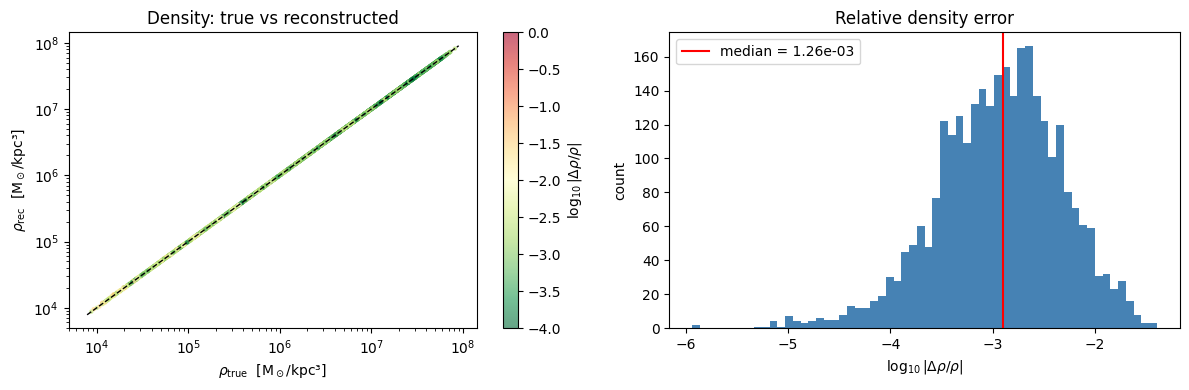

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# scatter: true vs reconstructed
ax = axes[0]
sc = ax.scatter(rho_true, rho_rec, c=np.log10(rel_err + 1e-10),
                cmap="RdYlGn_r", s=5, alpha=0.6, vmin=-4, vmax=0)
lims = [rho_true.min()*0.9, rho_true.max()*1.1]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$\rho_\mathrm{true}$  [M$_\odot$/kpc³]")
ax.set_ylabel(r"$\rho_\mathrm{rec}$  [M$_\odot$/kpc³]")
ax.set_title("Density: true vs reconstructed")
plt.colorbar(sc, ax=ax, label=r"$\log_{10}|\Delta\rho/\rho|$")

# error histogram
ax = axes[1]
ax.hist(np.log10(rel_err + 1e-10), bins=60, color="steelblue", edgecolor="none")
ax.axvline(np.log10(np.median(rel_err)), color="r", lw=1.5,
           label=f"median = {np.median(rel_err):.2e}")
ax.set_xlabel(r"$\log_{10}|\Delta\rho/\rho|$")
ax.set_ylabel("count")
ax.set_title("Relative density error")
ax.legend()

plt.tight_layout()
plt.show()

## 4. Gravitational potential in the x-z plane  [(km/s)²]

The code solves the Poisson equation with G = 1, so we multiply by G_phys to get the physical potential in kpc²/Myr², then convert to (km/s)²:

$$\Phi_\mathrm{phys} = G_\mathrm{phys} \times \Phi_\mathrm{code} \quad [\text{kpc}^2/\text{Myr}^2]$$
$$\Phi_{\text{km/s}^2} = \Phi_\mathrm{phys} \times (977.8 \; \text{km/s per kpc/Myr})^2$$

In [28]:
# 2-D evaluation grid in the x-z plane (y = 0)
ng  = 150
lim = 3 * r_s    # ±60 kpc
gv  = np.linspace(-lim, lim, ng)
XX, ZZ = np.meshgrid(gv, gv)     # kpc
YY = np.zeros_like(XX)

XJ = jnp.array(XX.ravel())
YJ = jnp.array(YY.ravel())
ZJ = jnp.array(ZZ.ravel())

# Physical potential in (km/s)²
phi_code = np.array(exp(XJ, YJ, ZJ)).reshape(ng, ng)
phi_phys = G_phys * phi_code                              # kpc²/Myr²
phi_kms2 = phi_phys * KPC_MYR_TO_KMS**2                  # (km/s)²

print(f"Φ range: [{phi_kms2.min():.1f}, {phi_kms2.max():.1f}]  (km/s)²")

Φ range: [-111568.3, -37901.7]  (km/s)²


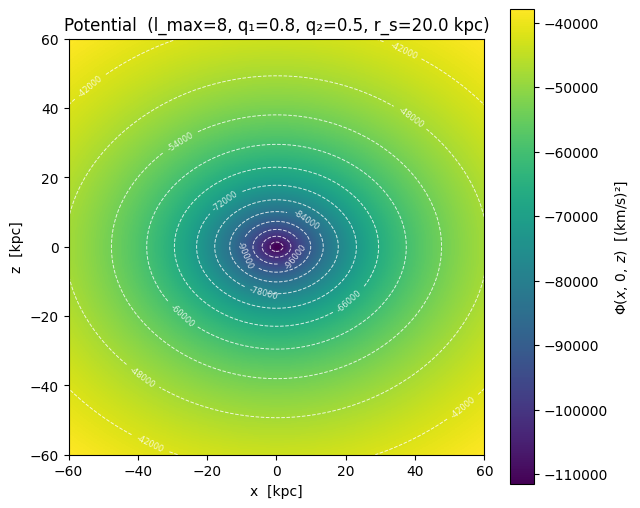

In [29]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

kw = dict(origin="lower", extent=[-lim, lim, -lim, lim], aspect="equal")
im = ax.imshow(phi_kms2, cmap="viridis", **kw)
plt.colorbar(im, ax=ax, label=r"$\Phi(x,\,0,\,z)$  [(km/s)²]")

cs = ax.contour(phi_kms2, 12, extent=[-lim, lim, -lim, lim],
                colors="w", linewidths=0.7, alpha=0.8)
ax.clabel(cs, fmt="%d", fontsize=6)

ax.set_xlabel("x  [kpc]")
ax.set_ylabel("z  [kpc]")
ax.set_title(f"Potential  (l_max={exp.l_max}, q₁={q1}, q₂={q2}, r_s={r_s} kpc)")
plt.tight_layout()
plt.show()

## 5. Acceleration field  [kpc/Myr²]

$$\mathbf{a}_\mathrm{phys} = G_\mathrm{phys} \times \mathbf{a}_\mathrm{code} \quad [\text{kpc/Myr}^2]$$

Computed via `jax.vmap(jax.grad(...))` through the spline representation of Φ.

In [30]:
ax_code, _, az_code = exp.acceleration(XJ, YJ, ZJ)
ax_phys = G_phys * np.array(ax_code).reshape(ng, ng)   # kpc/Myr²
az_phys = G_phys * np.array(az_code).reshape(ng, ng)
acc_mag = np.sqrt(ax_phys**2 + az_phys**2)             # kpc/Myr²

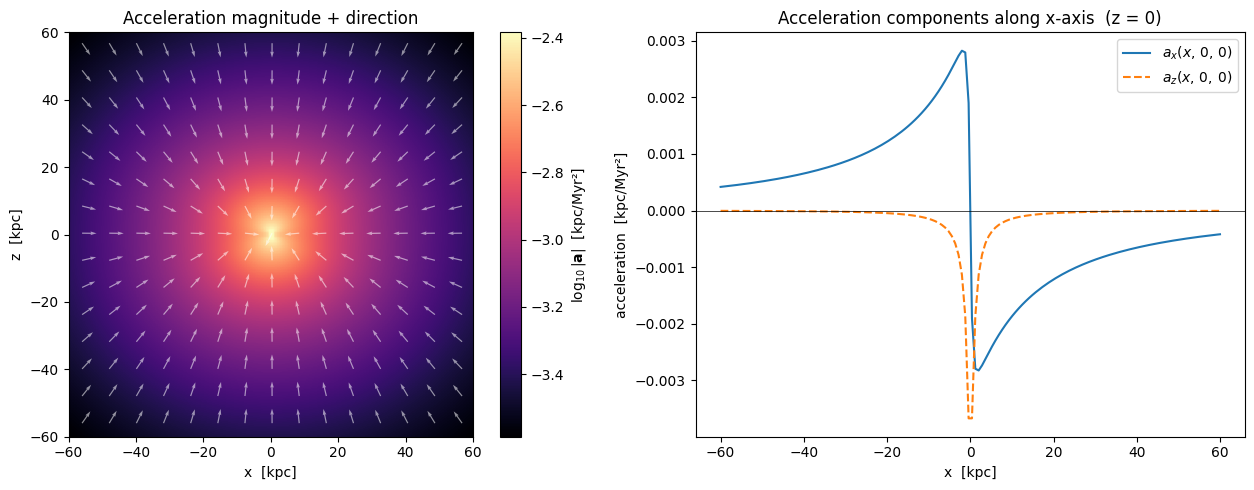

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── acceleration magnitude + direction arrows ──────────────────────────
ax = axes[0]
im = ax.imshow(np.log10(acc_mag + 1e-20), cmap="magma",
               origin="lower", extent=[-lim, lim, -lim, lim], aspect="equal")
plt.colorbar(im, ax=ax, label=r"$\log_{10}|\mathbf{a}|$  [kpc/Myr²]")

step = 10
sl   = slice(step//2, ng, step)
Xq, Zq  = XX[sl, sl], ZZ[sl, sl]
axq, azq = ax_phys[sl, sl], az_phys[sl, sl]
mq = np.sqrt(axq**2 + azq**2) + 1e-30
ax.quiver(Xq, Zq, axq/mq, azq/mq,
          color="white", alpha=0.55, scale=28, width=0.003)
ax.set_xlabel("x  [kpc]")
ax.set_ylabel("z  [kpc]")
ax.set_title("Acceleration magnitude + direction")

# ── x- and z-components along x-axis ──────────────────────────────────
ax = axes[1]
mid = ng // 2
ax.plot(gv, ax_phys[mid, :], label=r"$a_x(x,\,0,\,0)$", lw=1.5)
ax.plot(gv, az_phys[mid, :], label=r"$a_z(x,\,0,\,0)$", lw=1.5, ls="--")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("x  [kpc]")
ax.set_ylabel("acceleration  [kpc/Myr²]")
ax.set_title("Acceleration components along x-axis  (z = 0)")
ax.legend()

plt.tight_layout()
plt.show()

## 6. Circular velocity curve  [km/s]

In the equatorial plane along the x-axis, the circular velocity is

$$v_c(R) = \sqrt{R\,|a_x(R,0,0)|_\mathrm{phys}}\quad [\text{kpc/Myr}]$$

converted to km/s by multiplying by 977.8.  We also overlay the **analytical spherical NFW** curve as a reference; the BFE will deviate because the halo is triaxial.

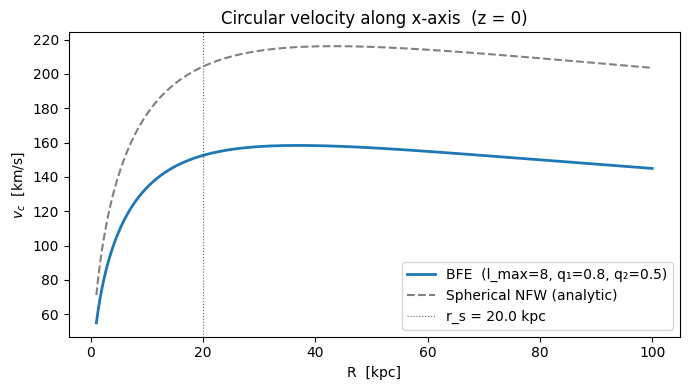

Peak BFE v_c       = 158.4 km/s  at R = 36.8 kpc
Peak analytic v_c  = 216.2 km/s  at R = 43.4 kpc


In [32]:
R_vals = np.linspace(1.0, 5 * r_s, 300)   # kpc, along x-axis
zeros  = np.zeros_like(R_vals)

ax_Rc, _, _ = exp.acceleration(
    jnp.array(R_vals), jnp.array(zeros), jnp.array(zeros)
)
ax_Rc_phys = G_phys * np.array(ax_Rc)   # kpc/Myr²  (negative = inward)

# v_c² = R * |a_x|  (centripetal balance)
vc_bfe = np.sqrt(np.maximum(R_vals * np.abs(ax_Rc_phys), 0.0))  # kpc/Myr
vc_bfe_kms = vc_bfe * KPC_MYR_TO_KMS                             # km/s

# Analytical spherical NFW for reference
def vc_nfw_spherical(R):
    """v_c [km/s] for a spherical NFW (rho_s, r_s) with G_phys."""
    x = R / r_s
    # enclosed mass: 4π rho_s r_s³ [ln(1+x) - x/(1+x)]
    M_enc = 4 * np.pi * rho_s * r_s**3 * (np.log(1 + x) - x / (1 + x))
    vc2   = G_phys * M_enc / R   # kpc²/Myr²
    return np.sqrt(np.maximum(vc2, 0.0)) * KPC_MYR_TO_KMS

vc_analytic = vc_nfw_spherical(R_vals)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(R_vals, vc_bfe_kms,  lw=2,   label=f"BFE  (l_max={exp.l_max}, q₁={q1}, q₂={q2})")
ax.plot(R_vals, vc_analytic, lw=1.5, ls="--", color="grey",
        label="Spherical NFW (analytic)")

ax.axvline(r_s, color="k", lw=0.8, ls=":", alpha=0.6, label=f"r_s = {r_s} kpc")
ax.set_xlabel("R  [kpc]")
ax.set_ylabel(r"$v_c$  [km/s]")
ax.set_title("Circular velocity along x-axis  (z = 0)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Peak BFE v_c       = {vc_bfe_kms.max():.1f} km/s  at R = {R_vals[vc_bfe_kms.argmax()]:.1f} kpc")
print(f"Peak analytic v_c  = {vc_analytic.max():.1f} km/s  at R = {R_vals[vc_analytic.argmax()]:.1f} kpc")

## 7. Radial mode amplitudes at r = r_s

The monopole (l=0) dominates; even-l quadrupole/hexadecapole modes carry the triaxial shape.

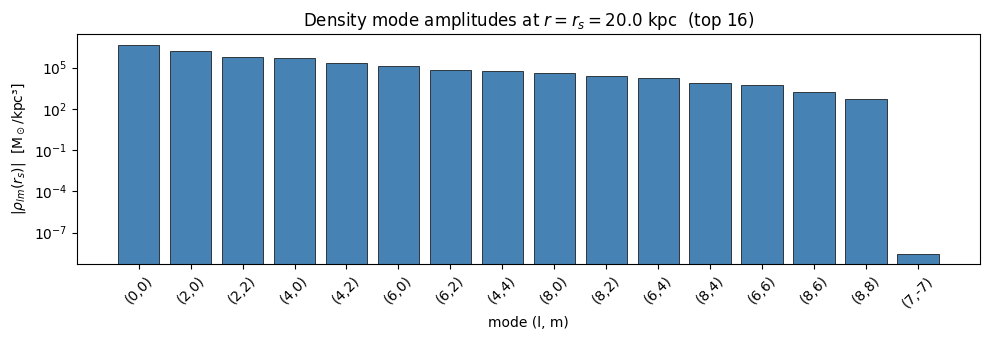

In [33]:
amps = exp.rho_lm_amplitudes(r_val=r_s)   # M☉/kpc³, at r = r_s

top    = sorted(amps.items(), key=lambda kv: kv[1], reverse=True)[:16]
labels = [f"({l},{m})" for (l, m), _ in top]
values = [v for _, v in top]

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(labels, values, color="steelblue", edgecolor="k", linewidth=0.5)
ax.set_yscale("log")
ax.set_xlabel("mode (l, m)")
ax.set_ylabel(r"$|\rho_{lm}(r_s)|$  [M$_\odot$/kpc³]")
ax.set_title(fr"Density mode amplitudes at $r = r_s = {r_s}$ kpc  (top 16)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 8. JIT-compiled batch throughput

In [34]:
import time

N_bench = 1_000_000
xb = jnp.array(rng.uniform(-100, 100, N_bench))   # kpc
yb = jnp.array(rng.uniform(-100, 100, N_bench))
zb = jnp.array(rng.uniform(-100, 100, N_bench))

# Warm-up (triggers XLA compilation)
_ = exp(xb, yb, zb).block_until_ready()

t0 = time.perf_counter()
_ = exp(xb, yb, zb).block_until_ready()
dt = time.perf_counter() - t0

print(f"{N_bench/1e6:.0f}M points in {dt*1.0:.1f} s  →  {N_bench/dt/1e6:.1f} M pts/s")